Resumption of project for senior thesis

File created 1/25/2025

In [1]:
from g4beam import *
from scan import *

import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
import numpy as np
import pandas as pd
from tqdm import *
import pickle
import itertools
from tabulate import tabulate
import scipy.optimize
import lzma
import os
import json

# Varying beta

## Test 1

Small-scale test, to establish meaningful ranges

In [31]:
t_emit = 0.145
momentum = 100  # MeV/c
# beta = 0.03    # m
betas = np.linspace(0.02, 0.04, 3)
alpha = 1     # dimensionless
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 1, 8
a_min, a_max = 10, 70
betas

array([0.02, 0.03, 0.04])

In [32]:
# Meta-function (containing optimization)
def metafun(beta):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [7, 45], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max)), options=dict(fatol=2e-4))

result = run_scan(metafun, (betas,), filename="results/optimal_scans/beta_test1.pkl", trials=2)

100%|███████████████████████████████████████████████████████████████████████████████████| 6/6 [19:52<00:00, 198.67s/it]


Saving to results/optimal_scans/beta_test1.pkl
Results saved


Text(0, 0.5, 'optimal half-angle (deg)')

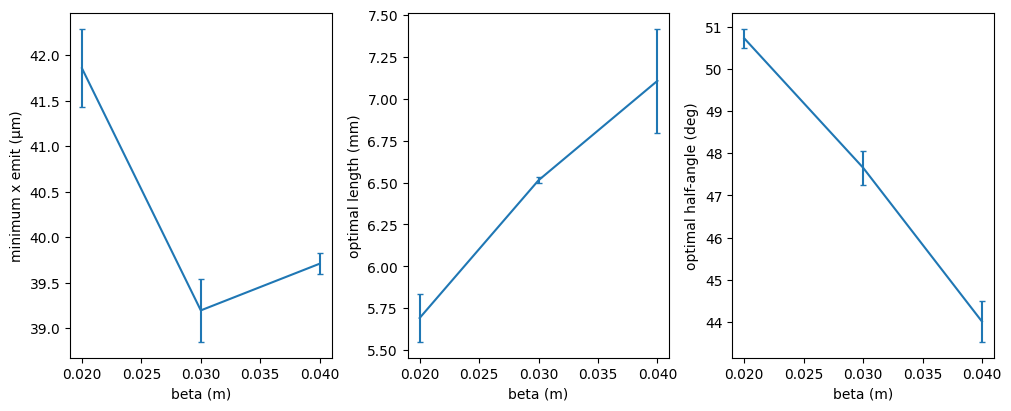

In [33]:
with open("results/optimal_scans/beta_test1.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"beta (m)")
ax1.set_ylabel("minimum x emit (μm)")

ax2.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"beta (m)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"beta (m)")
ax3.set_ylabel("optimal half-angle (deg)")

## Main test
Determined parameter ranges with some leeway: length 5-8 mm, half-angle 40-60 degrees, for a beta range of 0.02-0.04 m

In [74]:
t_emit = 0.145
momentum = 100  # MeV/c
# beta = 0.03    # m
betas = np.linspace(0.02, 0.04, 9)
alpha = 1     # dimensionless
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 40, 55
betas

array([0.02  , 0.0225, 0.025 , 0.0275, 0.03  , 0.0325, 0.035 , 0.0375,
       0.04  ])

In [52]:
# Meta-function (containing optimization)
def metafun(beta):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [6.5, 47], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max)), options=dict(fatol=1e-3))

result = run_scan(metafun, (betas,), filename="results/optimal_scans/beta_a10.pkl", trials=5)

100%|███████████████████████████████████████████████████████████████████████████████| 45/45 [2:28:36<00:00, 198.14s/it]


Saving to results/optimal_scans/beta_a10.pkl
Results saved


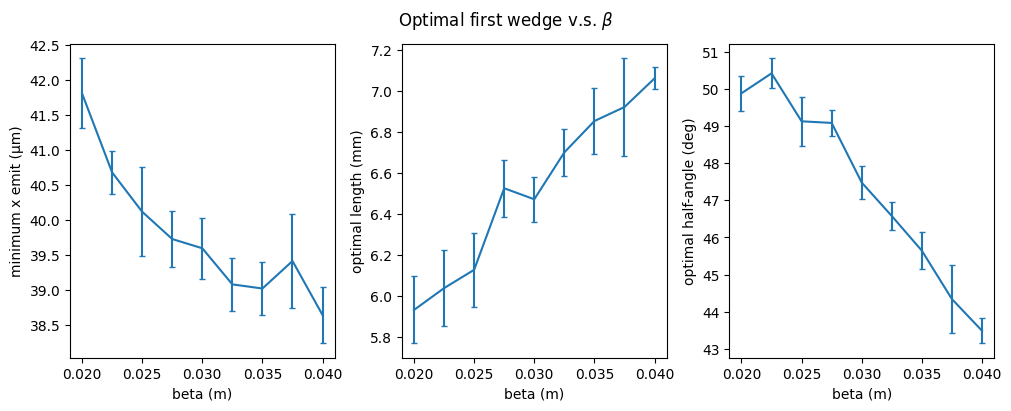

In [75]:
with open("results/optimal_scans/beta_a10.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"beta (m)")
ax1.set_ylabel("minimum x emit (μm)")

ax2.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"beta (m)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"beta (m)")
ax3.set_ylabel("optimal half-angle (deg)")

fig.suptitle(r"Optimal first wedge v.s. $\beta$")

plt.savefig("./visuals/2025/beta_optim.png")

# Varying alpha

## Test 1
Similar small-scale test, prepared for run

In [41]:
t_emit = 0.145
momentum = 100  # MeV/c
beta = 0.03    # m
# betas = np.linspace(0.02, 0.04, 3)
# alpha = 1     # dimensionless
alphas = np.linspace(-0.5, 1, 4)
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 1, 8
a_min, a_max = 10, 70
alphas

array([-0.5,  0. ,  0.5,  1. ])

In [36]:
# Meta-function (containing optimization)
def metafun(alpha):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [7, 45], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max)), options=dict(fatol=2e-4))

result = run_scan(metafun, (alphas,), filename="results/optimal_scans/alpha_test1.pkl", trials=2)

100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [29:41<00:00, 222.67s/it]


Saving to results/optimal_scans/alpha_test1.pkl
Results saved


Text(0, 0.5, 'optimal half-angle (deg)')

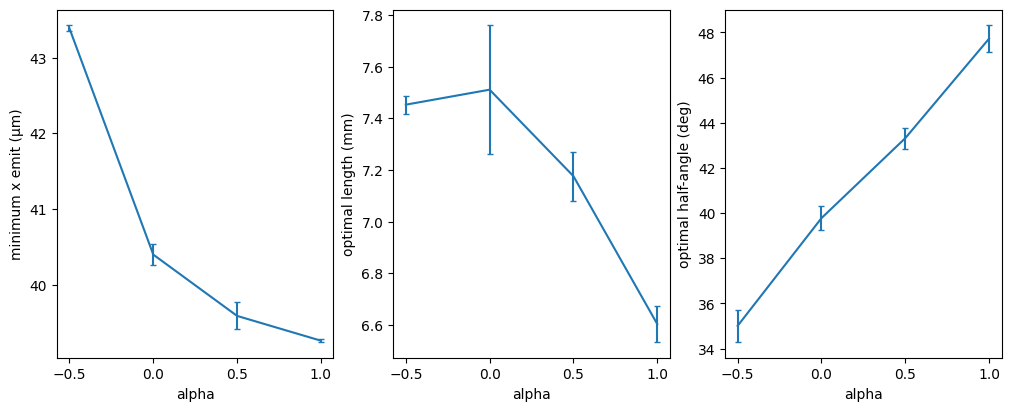

In [37]:
with open("results/optimal_scans/alpha_test1.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"alpha")
ax1.set_ylabel("minimum x emit (μm)")

ax2.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"alpha")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"alpha")
ax3.set_ylabel("optimal half-angle (deg)")

## Test 2
Attempt to extend the range beyond 1.0, also testing changing the fatol to 1e-3

In [64]:
t_emit = 0.145
momentum = 100  # MeV/c
beta = 0.03    # m
# betas = np.linspace(0.02, 0.04, 3)
# alpha = 1     # dimensionless
alphas = np.linspace(0.5, 1.5, 3)
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 1, 8
a_min, a_max = 10, 70
alphas

array([0.5, 1. , 1.5])

In [47]:
# Meta-function (containing optimization)
def metafun(alpha):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [7, 45], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max)), options=dict(fatol=1e-3))

result = run_scan(metafun, (alphas,), filename="results/optimal_scans/alpha_test2.pkl", trials=2)

100%|███████████████████████████████████████████████████████████████████████████████████| 6/6 [20:41<00:00, 206.92s/it]


Saving to results/optimal_scans/alpha_test2.pkl
Results saved


Text(0, 0.5, 'optimal half-angle (deg)')

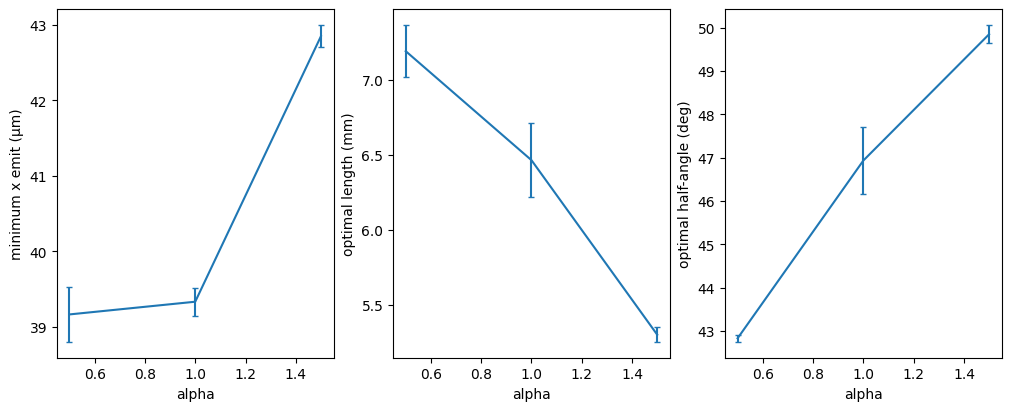

In [66]:
with open("results/optimal_scans/alpha_test2.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"alpha")
ax1.set_ylabel("minimum x emit (μm)")

ax2.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"alpha")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"alpha")
ax3.set_ylabel("optimal half-angle (deg)")

## Main test

In [71]:
t_emit = 0.145
momentum = 100  # MeV/c
beta = 0.03    # m
# betas = np.linspace(0.02, 0.04, 3)
# alpha = 1     # dimensionless
alphas = np.linspace(0, 1.5, 9)
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 33, 53
alphas

array([0.    , 0.1875, 0.375 , 0.5625, 0.75  , 0.9375, 1.125 , 1.3125,
       1.5   ])

In [56]:
# Meta-function (containing optimization)
def metafun(alpha):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [6.5, 45], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max)), options=dict(fatol=1e-3))

result = run_scan(metafun, (alphas,), filename="results/optimal_scans/alpha_b30.pkl", trials=5)

100%|███████████████████████████████████████████████████████████████████████████████| 45/45 [2:31:04<00:00, 201.44s/it]


Saving to results/optimal_scans/alpha_b30.pkl
Results saved


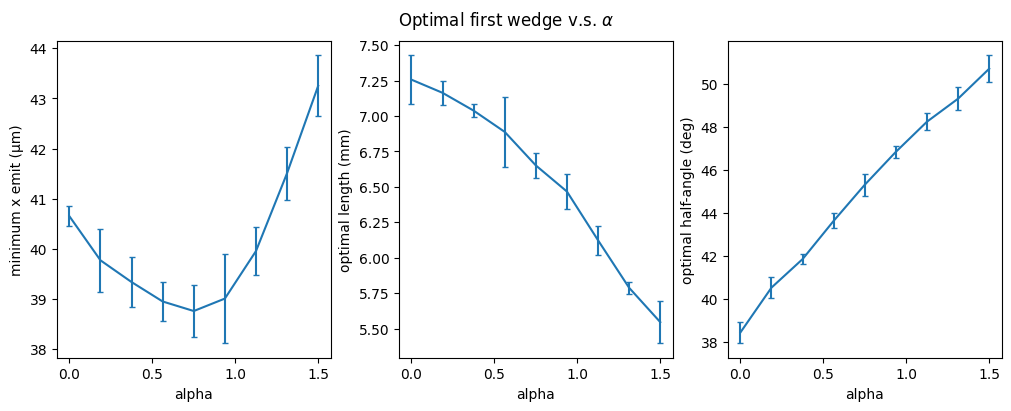

In [73]:
with open("results/optimal_scans/alpha_b30.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"alpha")
ax1.set_ylabel("minimum x emit (μm)")

ax2.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"alpha")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"alpha")
ax3.set_ylabel("optimal half-angle (deg)")

fig.suptitle(r"Optimal first wedge v.s. $\alpha$")

plt.savefig("./visuals/2025/alpha_optim.png")

# Optimization with alpha as a variable

## First run

In [78]:
# Initial experiment
t_emit = 0.145
momentum = 100  # MeV/c
beta = 0.03    # m
# alpha = 1     # dimensionless
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 40, 55
    
def func(x):
    length, angle, alpha = x
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

res = list()
for _ in range(5):
    res.append(minimize(func, [6.5, 47, 0.5], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max), (0, 1)), options=dict(fatol=5e-3)))

iter value
  42 3.81713e-02
iter value
  42 3.77335e-02
iter value
  37 3.77899e-02
iter value
  44 3.76143e-02
iter value
  36 3.80950e-02


In [81]:
print(pd.DataFrame({
    "Run": np.arange(1, 6),
    "x1": [r.x[0] for r in res],
    "x2": [r.x[1] for r in res],
    "x3": [r.x[2] for r in res],
    "Final Function Value": [r.fun for r in res]
}))

   Run        x1         x2        x3  Final Function Value
0    1  6.908695  42.845341  0.519546              0.038171
1    2  6.908832  43.715023  0.535097              0.037733
2    3  6.591758  43.901992  0.507193              0.037790
3    4  6.804697  42.504731  0.520910              0.037614
4    5  6.533230  45.570588  0.536185              0.038095


In [94]:
# Cell for quick experiments

t_emit = 0.145
momentum = 100  # MeV/c
beta = 0.03    # m
# alpha = 1     # dimensionless
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 40, 55
    
def func(x):
    length, angle, alpha = x
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=20000)
    return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

%time minimize(func, [6.5, 47, 0.5], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max), (0, 1)), options=dict(fatol=5e-3))

iter value
  41 3.83710e-02
CPU times: total: 19 s
Wall time: 7min 16s


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.038371031298763986
             x: [ 6.962e+00  4.361e+01  5.008e-01]
           nit: 41
          nfev: 107
 final_simplex: (array([[ 6.962e+00,  4.361e+01,  5.008e-01],
                       [ 6.962e+00,  4.361e+01,  5.008e-01],
                       [ 6.962e+00,  4.361e+01,  5.008e-01],
                       [ 6.962e+00,  4.361e+01,  5.008e-01]]), array([ 3.837e-02,  3.871e-02,  3.959e-02,  4.020e-02]))

Demonstrated that the idea works. We can do the main run now

In [82]:
t_emit = 0.145
momentum = 100  # MeV/c
# beta = 0.03    # m
betas = np.linspace(0.02, 0.04, 9)
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 20, 60
betas

array([0.02  , 0.0225, 0.025 , 0.0275, 0.03  , 0.0325, 0.035 , 0.0375,
       0.04  ])

In [84]:
# Meta-function (containing optimization)
def metafun(beta):
    
    def func(x):
        length, angle, alpha = x
        pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [6.5, 40, 0.5], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max), (0, 1)), options=dict(fatol=5e-3))

result = run_scan(metafun, (betas,), filename="results/optimal_scans/beta_var_alpha.pkl", trials=5)

100%|███████████████████████████████████████████████████████████████████████████████| 45/45 [3:18:15<00:00, 264.35s/it]


Saving to results/optimal_scans/beta_var_alpha.pkl
Results saved


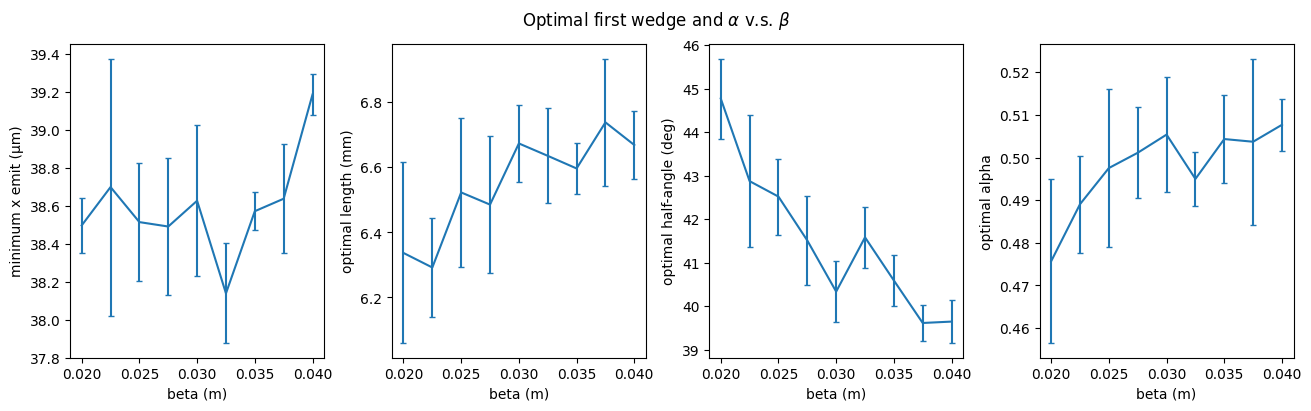

In [85]:
with open("results/optimal_scans/beta_var_alpha.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

def optim_x3(optim_result):
    return optim_result.x[2]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(ncols=4, layout="constrained")
fig.set_size_inches(13, 4)
ax1.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"beta (m)")
ax1.set_ylabel("minimum x emit (μm)")

ax2.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"beta (m)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"beta (m)")
ax3.set_ylabel("optimal half-angle (deg)")

ax4.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x3, results)), capsize=2)
ax4.set_xlabel(r"beta (m)")
ax4.set_ylabel("optimal alpha")

fig.suptitle(r"Optimal first wedge and $\alpha$ v.s. $\beta$")

plt.savefig("./visuals/2025/beta_optim_alpha.png")

A comparison: What happens if you lower `fatol`?

In [86]:
# Initial experiment
t_emit = 0.145
momentum = 100  # MeV/c
beta = 0.03    # m
# alpha = 1     # dimensionless
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 40, 55
    
def func(x):
    length, angle, alpha = x
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

res = list()
for _ in range(5):
    res.append(minimize(func, [6.5, 47, 0.5], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max), (0, 1)), options=dict(fatol=1e-4)))

iter value
  53 3.84761e-02
iter value
 225 3.80227e-02
iter value
 215 3.80754e-02
iter value
 234 3.76659e-02
iter value
 226 3.75708e-02


In [87]:
print(pd.DataFrame({
    "Run": np.arange(1, 6),
    "x1": [r.x[0] for r in res],
    "x2": [r.x[1] for r in res],
    "x3": [r.x[2] for r in res],
    "Final Function Value": [r.fun for r in res]
}))

   Run        x1         x2        x3  Final Function Value
0    1  6.834043  45.248040  0.509752              0.038476
1    2  6.725026  41.671399  0.511163              0.038023
2    3  7.024276  41.236328  0.522889              0.038075
3    4  6.557389  44.709938  0.514628              0.037666
4    5  6.825000  42.300000  0.525000              0.037571


Prohibitive instability, got it

## Second run
The big change is going up to 50K particles to hopefully curb error

In [82]:
t_emit = 0.145
momentum = 100  # MeV/c
# beta = 0.03    # m
betas = np.linspace(0.02, 0.04, 9)
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 20, 60
al_min, al_max = 0.4, 0.6
betas

array([0.02  , 0.0225, 0.025 , 0.0275, 0.03  , 0.0325, 0.035 , 0.0375,
       0.04  ])

In [84]:
# Meta-function (containing optimization)
def metafun(beta):
    
    def func(x):
        length, angle, alpha = x
        pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=50000)
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [6.5, 40, 0.5], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max), (al_min, al_max)), options=dict(fatol=5e-3))

result = run_scan(metafun, (betas,), filename="results/optimal_scans/beta_var_alpha.pkl", trials=5)

100%|███████████████████████████████████████████████████████████████████████████████| 45/45 [3:18:15<00:00, 264.35s/it]


Saving to results/optimal_scans/beta_var_alpha.pkl
Results saved


In [ ]:
with open("results/optimal_scans/beta_var_alpha.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

def optim_x3(optim_result):
    return optim_result.x[2]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(ncols=4, layout="constrained")
fig.set_size_inches(13, 4)
ax1.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"beta (m)")
ax1.set_ylabel("minimum x emit (μm)")

ax2.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"beta (m)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"beta (m)")
ax3.set_ylabel("optimal half-angle (deg)")

ax4.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x3, results)), capsize=2)
ax4.set_xlabel(r"beta (m)")
ax4.set_ylabel("optimal alpha")

fig.suptitle(r"Optimal first wedge and $\alpha$ v.s. $\beta$")

plt.savefig("./visuals/2025/beta_optim_alpha.png")